First 5 rows:
       CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   

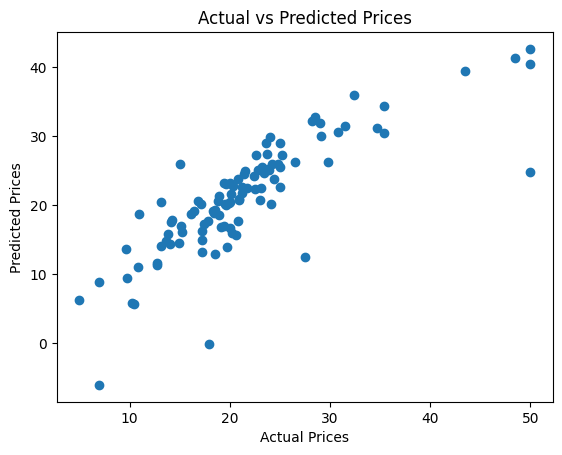


Feature Importance:
     Feature  Coefficient
5        RM     4.438835
3      CHAS     2.784438
8       RAD     0.262430
2     INDUS     0.040381
1        ZN     0.030110
11        B     0.012351
6       AGE    -0.006296
9       TAX    -0.010647
0      CRIM    -0.113056
12    LSTAT    -0.508571
10  PTRATIO    -0.915456
7       DIS    -1.447865
4       NOX   -17.202633

Sample Input:
         CRIM   ZN  INDUS  CHAS   NOX     RM   AGE     DIS  RAD    TAX  \
173  0.09178  0.0   4.05     0  0.51  6.416  84.1  2.6463    5  296.0   

     PTRATIO      B  LSTAT  
173     16.6  395.5   9.04  
Predicted Price: 28.996723619824888
Actual Price: 23.6

Custom Prediction: 36.0255653356723


In [7]:
# =========================================
# STEP 1: IMPORT LIBRARIES
# =========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# =========================================
# STEP 2: LOAD DATASET
# =========================================
df = pd.read_csv("boston.csv")

print("First 5 rows:\n", df.head())
print("\nDataset Info:")
print(df.info())

# =========================================
# STEP 3: BASIC ANALYSIS
# =========================================
print("\nStatistical Summary:\n", df.describe())

# =========================================
# STEP 4: DATA CLEANING
# =========================================
df = df.dropna()

# =========================================
# STEP 5: DEFINE FEATURES & TARGET
# =========================================
# MEDV = house price

X = df.drop('MEDV', axis=1)
y = df['MEDV']

# =========================================
# STEP 6: TRAIN-TEST SPLIT
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================
# STEP 7: TRAIN MODEL
# =========================================
model = LinearRegression()
model.fit(X_train, y_train)

# =========================================
# STEP 8: PREDICTIONS
# =========================================
y_pred = model.predict(X_test)

# =========================================
# STEP 9: EVALUATION
# =========================================
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

# =========================================
# STEP 10: VISUALIZATION
# =========================================
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

# =========================================
# STEP 11: FEATURE IMPORTANCE
# =========================================
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print("\nFeature Importance:\n", coeff_df.sort_values(by='Coefficient', ascending=False))

# =========================================
# STEP 12: SAFE PREDICTION (NO WARNING)
# =========================================
# IMPORTANT: Keep DataFrame format (not .values)

sample = X_test.iloc[[0]]   # double brackets = keeps column names
predicted_price = model.predict(sample)

print("\nSample Input:\n", sample)
print("Predicted Price:", predicted_price[0])
print("Actual Price:", y_test.iloc[0])

# =========================================
# STEP 13: CUSTOM PREDICTION FUNCTION
# =========================================
def predict_house_price(input_data):
    input_df = pd.DataFrame([input_data], columns=X.columns)
    return model.predict(input_df)[0]

# Example usage
example = X_test.iloc[1].to_dict()
print("\nCustom Prediction:", predict_house_price(example))